# **Filtrado Colaborativo con NMF**

Este cuaderno implementa y evalúa el filtrado colaborativo utilizando Factorización de Matrices No-Negativas (NMF) para recomendaciones de razas de perros.


## **1. Carga de Datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = [10, 6]

# Cargar matriz de ratings
ratings_matrix = pd.read_csv("data/user_dog_ratings.csv", index_col=0)

# Cargar datos de razas para referencia
df = pd.read_csv("data/akc-data-latest.csv")

print(f"Dimensiones de la matriz de ratings: {ratings_matrix.shape}")

Dimensiones de la matriz de ratings: (150, 277)


## **2. Introducción a NMF para Sistemas de Recomendación**

La Factorización de Matrices No-Negativas (NMF) es una técnica de factorización de matrices que descompone la matriz de ratings R en dos matrices de menor dimensión W y H:

$$R ≈ W \times H$$

Donde:
- R es la matriz de ratings usuario-ítem (m × n)
- W es la matriz de factores latentes de usuarios (m × k)
- H es la matriz de factores latentes de ítems (k × n)
- k es el número de factores latentes (mucho menor que m y n)

Las ventajas de NMF incluyen:
1. Capacidad para manejar matrices dispersas
2. Puede capturar relaciones complejas entre usuarios e ítems

## **3. Implementación de NMF**

In [2]:
from models.collaborative_nmf import factorize_with_nmf, recommend_from_nmf

# Definir número de factores latentes
n_factors = 20

# Factorizar la matriz
print("Factorizando la matriz de ratings con NMF...")
predicted_ratings, W, H = factorize_with_nmf(ratings_matrix, n_components=n_factors, return_model=True)

print(f"Dimensiones de la matriz W (usuarios): {W.shape}")
print(f"Dimensiones de la matriz H (ítems): {H.shape}")
print(f"Dimensiones de la matriz de ratings predichos: {predicted_ratings.shape}")

Factorizando la matriz de ratings con NMF...
Dimensiones de la matriz W (usuarios): (150, 20)
Dimensiones de la matriz H (ítems): (20, 277)
Dimensiones de la matriz de ratings predichos: (150, 277)


/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


## **4. Exploración del Espacio Latente**

10 razas no tienen grupo asignado: ['chinese_shar_pei', "cirneco_dell'etna", 'curly_coated_retriever', 'danish_swedish_farmdog', 'flat_coated_retriever']...


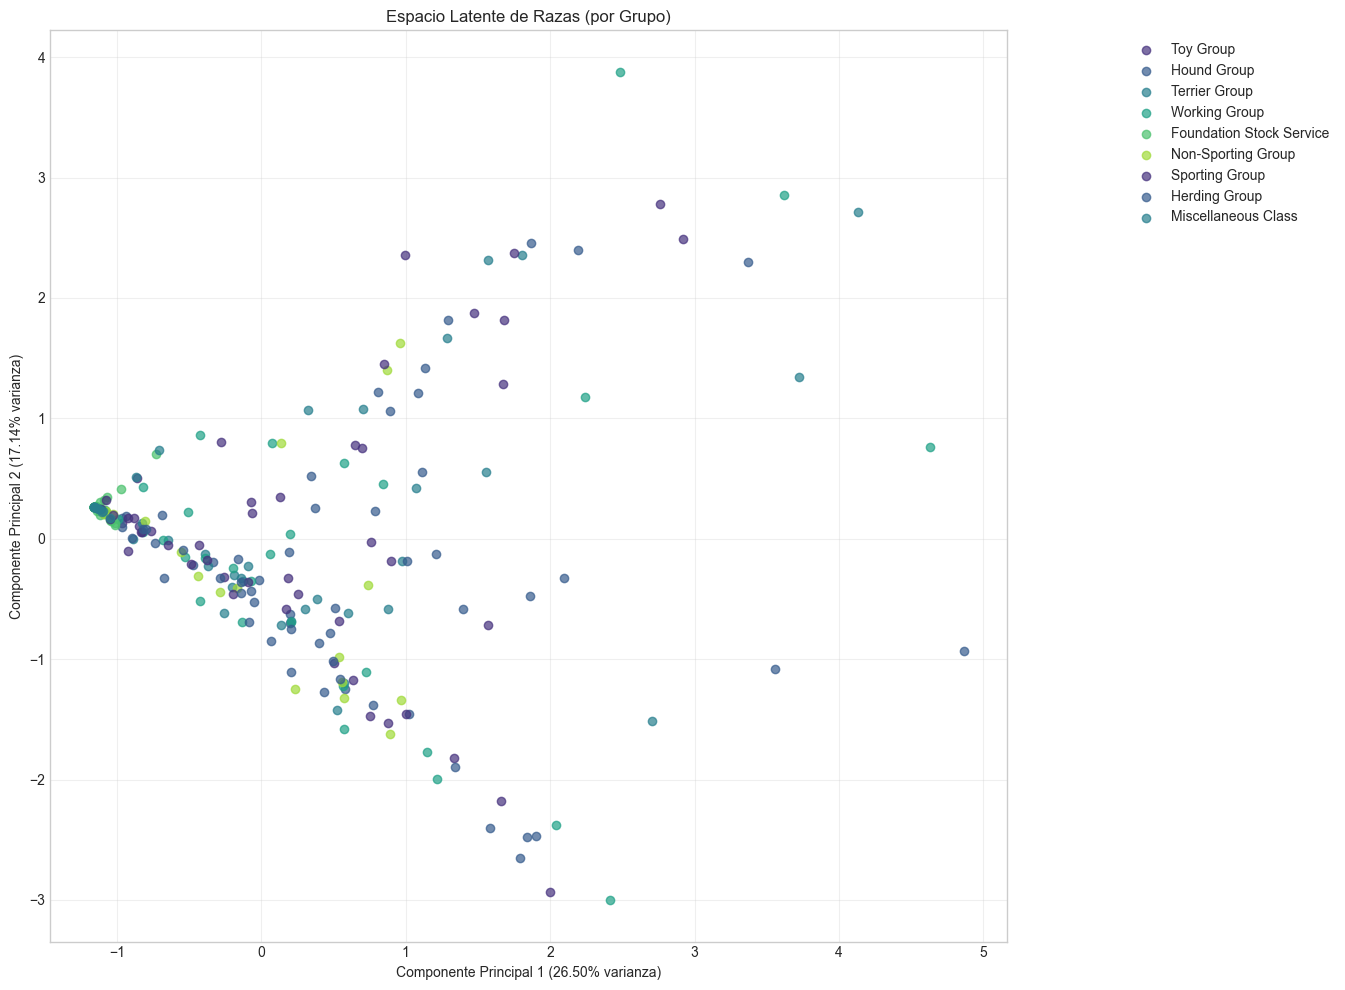

In [3]:
from sklearn.decomposition import PCA

# 4.1 Visualizar los factores latentes de los ítems usando PCA
pca = PCA(n_components=2)
item_factors_2d = pca.fit_transform(H.T)  # Transponer para que cada fila sea un ítem

# Crear DataFrame para visualización
df_latent = pd.DataFrame({
    'x': item_factors_2d[:, 0],
    'y': item_factors_2d[:, 1],
    'breed': ratings_matrix.columns,
})

# Normalizar los nombres de razas para el mapeo
# Convertir los nombres en df['breed'] a snake_case para que coincidan con ratings_matrix.columns
df_breed_mapping = df.copy()
df_breed_mapping['breed_normalized'] = df['breed'].str.lower().str.replace(' ', '_')

# Crear mapeo usando los nombres normalizados
breed_to_group = dict(zip(df_breed_mapping['breed_normalized'], df_breed_mapping['group']))

# Usar el nombre normalizado para el mapeo
df_latent['group'] = df_latent['breed'].map(breed_to_group)

# Verificar si hay alguna raza sin grupo asignado
nan_breeds = df_latent[df_latent['group'].isna()]['breed'].tolist()
if nan_breeds:
    print(f"{len(nan_breeds)} razas no tienen grupo asignado: {nan_breeds[:5]}...")

# Visualización por grupo
plt.figure(figsize=(14, 10))
groups = df_latent['group'].dropna().unique()

for group in groups:
    subset = df_latent[df_latent['group'] == group]
    plt.scatter(subset['x'], subset['y'], alpha=0.7, label=group)

plt.title('Espacio Latente de Razas (por Grupo)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Factor latente #1:


,Raza,Valor,Group
0,american_water_spaniel,0.952415,Sporting Group
1,xoloitzcuintli,0.914016,Non-Sporting Group
2,entlebucher_mountain_dog,0.890567,Herding Group
3,bearded_collie,0.878647,Herding Group
4,miniature_pinscher,0.838973,Toy Group


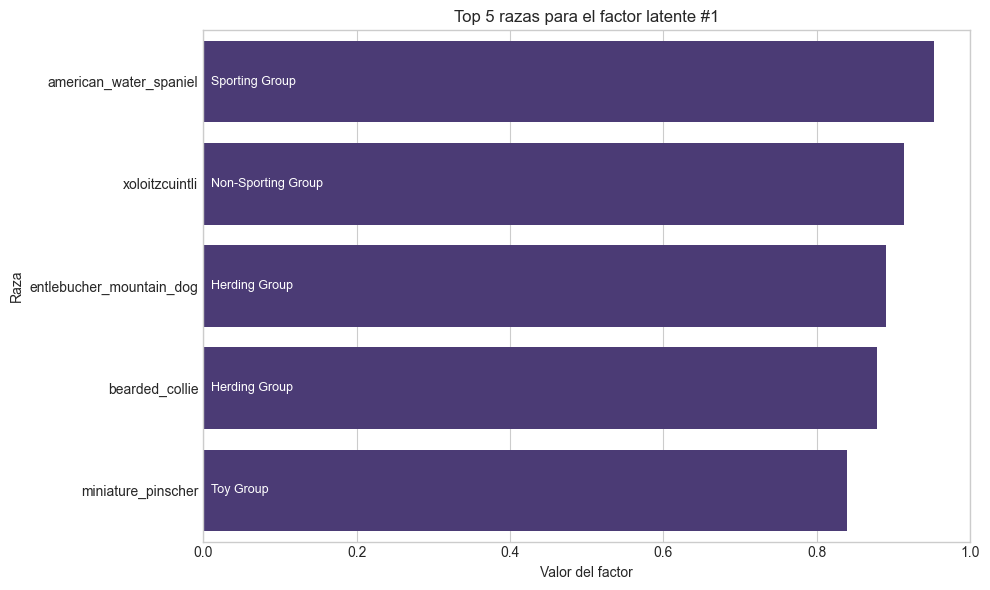


Factor latente #2:


,Raza,Valor,Group
0,finnish_spitz,1.537841,Non-Sporting Group
1,icelandic_sheepdog,1.430577,Herding Group
2,soft_coated_wheaten_terrier,1.355654,Terrier Group
3,tibetan_mastiff,1.256182,Working Group
4,norfolk_terrier,1.188058,Terrier Group


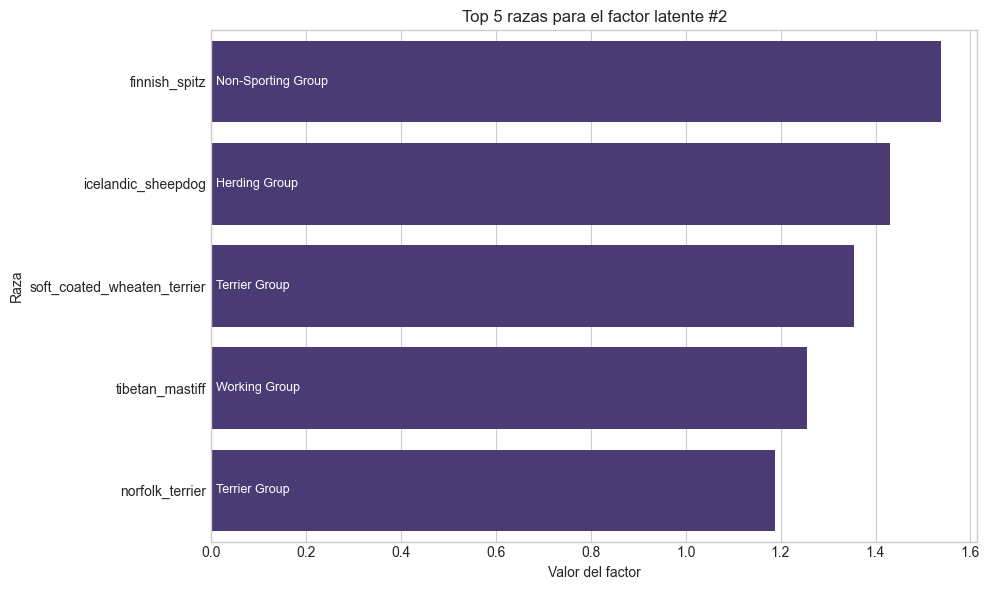


Factor latente #3:


,Raza,Valor,Group
0,wirehaired_vizsla,1.712680,Sporting Group
1,american_staffordshire_terrier,1.621235,Terrier Group
2,newfoundland,1.618187,Working Group
3,coton_de_tulear,1.605224,Non-Sporting Group
4,soft_coated_wheaten_terrier,1.560063,Terrier Group


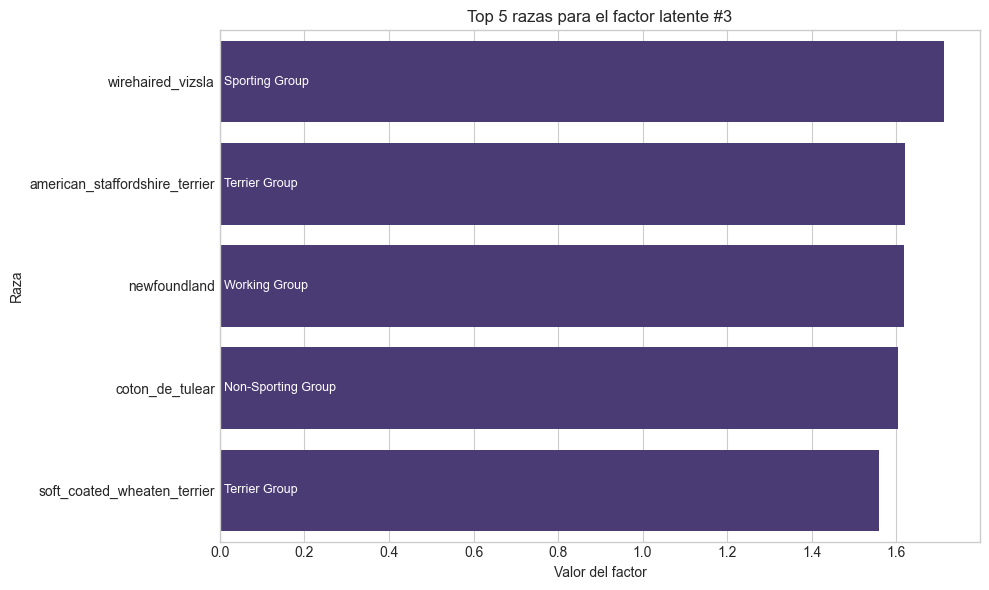


Factor latente #4:


,Raza,Valor,Group
0,affenpinscher,2.613005,Toy Group
1,puli,2.277595,Herding Group
2,belgian_sheepdog,1.957109,Herding Group
3,sloughi,1.783522,Hound Group
4,english_foxhound,1.541085,Hound Group


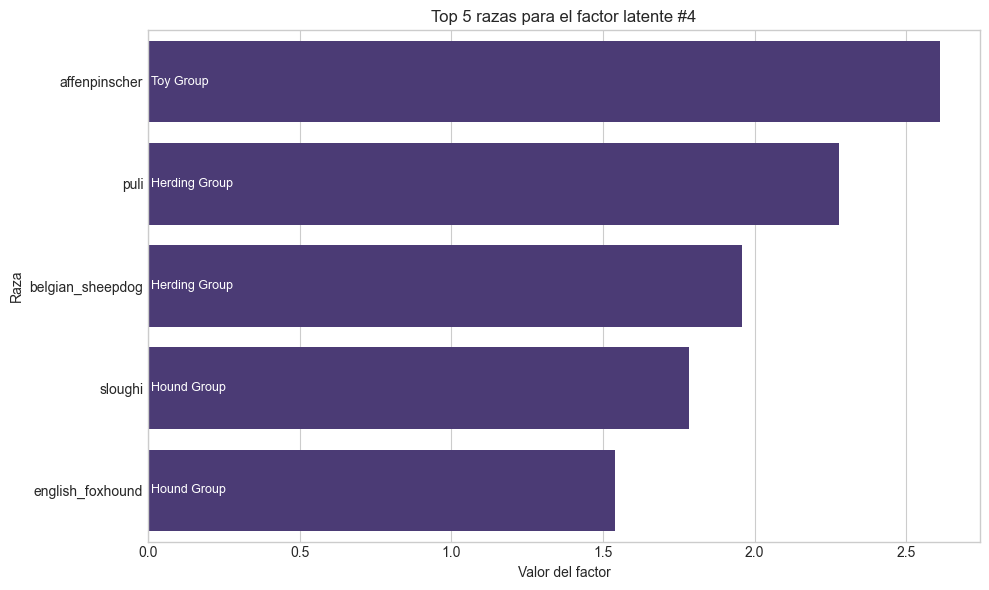


Factor latente #5:


,Raza,Valor,Group
0,finnish_lapphund,1.102292,Herding Group
1,australian_cattle_dog,1.071816,Herding Group
2,english_foxhound,1.002911,Hound Group
3,miniature_bull_terrier,1.001677,Terrier Group
4,gordon_setter,0.998970,Sporting Group


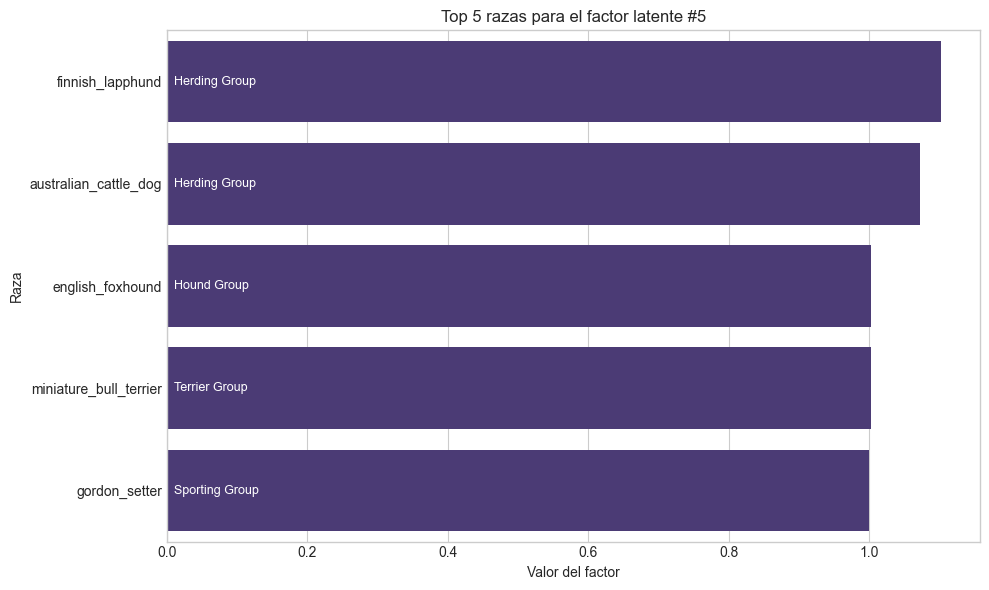

In [4]:
# 4.2 Análisis de factores latentes
# Veamos qué razas tienen los valores más altos para cada factor

num_factors_to_show = min(5, n_factors)  # Mostrar los primeros 5 factores o menos
top_k_breeds = 5  # Top 5 razas por factor

for factor_idx in range(num_factors_to_show):
    # Obtener las razas con mayor valor para este factor
    factor_values = H[factor_idx, :]
    top_indices = np.argsort(factor_values)[::-1][:top_k_breeds]
    top_breeds = ratings_matrix.columns[top_indices]
    top_values = factor_values[top_indices]
    
    # Crear DataFrame con la información
    top_factor_df = pd.DataFrame({
        'Raza': top_breeds,
        'Valor': top_values
    })
    
    # Añadir información de grupo
    top_factor_df['Group'] = top_factor_df['Raza'].map(breed_to_group)
    
    print(f"\nFactor latente #{factor_idx+1}:")
    display(top_factor_df)
    
    # Visualización de este factor
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Valor', y='Raza', data=top_factor_df)
    plt.title(f'Top {top_k_breeds} razas para el factor latente #{factor_idx+1}')
    plt.xlabel('Valor del factor')
    
    # Añadir etiqueta de grupo
    for i, row in enumerate(top_factor_df.itertuples()):
        plt.text(0.01, i, row.Group, fontsize=9, ha='left', va='center', color='white')
        
    plt.tight_layout()
    plt.show()

## **5. Generación de Recomendaciones**

In [5]:
# 5.1 Elegir algunos usuarios para probar recomendaciones
# Primero, cargar los datos de las razas para poder mostrar información adicional
import pandas as pd

# Cargar el dataset con información detallada de las razas
dog_df = pd.read_csv('data/akc-data-latest.csv')
# Normalizar los nombres de las razas para que coincidan con los de la matriz de ratings
from pipeline.preprocessing import normalize_breed_name
dog_df['breed'] = dog_df['breed'].apply(normalize_breed_name)

test_users = np.random.choice(ratings_matrix.index, size=3, replace=False)

for user_id in test_users:
    # Obtener ratings del usuario
    user_ratings = ratings_matrix.loc[user_id]
    rated_breeds = user_ratings[user_ratings > 0]
    favorite_breeds = user_ratings[user_ratings >= 4].index.tolist()
    
    print(f"\nUsuario: {user_id}")
    print(f"Número de razas valoradas: {len(rated_breeds)}")
    print(f"Razas favoritas: {', '.join(favorite_breeds[:5])}{'...' if len(favorite_breeds) > 5 else ''}")
    
    # Generar recomendaciones
    # Obtener la lista de índices de razas que el usuario ya ha valorado
    known_items = rated_breeds.index.tolist()
    recs = recommend_from_nmf(predicted_ratings, user_id, known_items, top_k=10)
    
    print("Recomendaciones:")
    
    # Añadir información adicional
    recs_with_info = pd.merge(
        recs, 
        dog_df[['breed', 'group', 'temperament']], 
        left_on='index', 
        right_on='breed'
    )[['breed', 'nmf_score', 'group', 'temperament']]
    
    # Mostrar las recomendaciones
    display(recs_with_info)


Usuario: User34
Número de razas valoradas: 55
Razas favoritas: affenpinscher, american_english_coonhound, american_water_spaniel, australian_cattle_dog, beauceron...
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 222
Top 10 recomendaciones generadas con éxito
Recomendaciones:


,breed,nmf_score,group,temperament
0,nova_scotia_duck_tolling_retriever,2.733854,Sporting Group,"Affectionate, Intelligent, Outgoing"
1,ibizan_hound,2.678485,Hound Group,"Family-Oriented, Even-Tempered, Polite"
2,flat_coated_retriever,2.518636,Sporting Group,"Cheerful, Optimistic, Good-Humored"
3,otterhound,2.367563,Hound Group,"Even-Tempered, Amiable, Boisterous"
4,bergamasco_sheepdog,2.300713,Herding Group,"Independent, Sociable, Intelligent"
5,tibetan_spaniel,2.300013,Non-Sporting Group,"Playful, Bright, Self-Confident"
6,greyhound,2.297528,Hound Group,"Gentle, Independent, Noble"
7,glen_of_imaal_terrier,2.295406,Terrier Group,"Gentle, Spirited, Bold"
8,dalmatian,2.285827,Non-Sporting Group,"Dignified, Smart, Outgoing"
9,norwegian_buhund,2.275589,Herding Group,"Confident, Smart, Perceptive"



Usuario: User56
Número de razas valoradas: 63
Razas favoritas: affenpinscher, american_eskimo_dog, american_water_spaniel, australian_terrier, basset_hound...
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 214
Top 10 recomendaciones generadas con éxito
Recomendaciones:


,breed,nmf_score,group,temperament
0,scottish_deerhound,3.505513,Hound Group,"Gentle, Dignified, Polite"
1,boerboel,2.673332,Working Group,"Confident, Intelligent, Calm"
2,irish_red_and_white_setter,2.588458,Sporting Group,"Courageous, Spirited, Determined"
3,swedish_vallhund,2.355615,Herding Group,"Friendly, Energetic, Watchful"
4,pyrenean_shepherd,2.305470,Herding Group,"Affectionate, Active, Enthusiastic"
5,norwegian_buhund,2.294755,Herding Group,"Confident, Smart, Perceptive"
6,curly_coated_retriever,2.215632,Sporting Group,"Confident, Proud, Wickedly Smart"
7,american_hairless_terrier,2.152491,Terrier Group,"Energetic, Alert, Curious"
8,spinone_italiano,2.057809,Sporting Group,"Sociable, Patient, Docile"
9,boykin_spaniel,2.009341,Sporting Group,"Friendly, Eager, Lovable"



Usuario: User53
Número de razas valoradas: 59
Razas favoritas: alaskan_malamute, australian_shepherd, berger_picard, border_terrier, canaan_dog...
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 218
Top 10 recomendaciones generadas con éxito
Recomendaciones:


,breed,nmf_score,group,temperament
0,spinone_italiano,2.415420,Sporting Group,"Sociable, Patient, Docile"
1,portuguese_podengo_pequeno,2.303669,Hound Group,"Playful, Charming, Lively"
2,irish_red_and_white_setter,2.263353,Sporting Group,"Courageous, Spirited, Determined"
3,borzoi,2.203453,Hound Group,"Affectionate, Loyal, Regally Dignified"
4,bergamasco_sheepdog,2.182379,Herding Group,"Independent, Sociable, Intelligent"
5,field_spaniel,2.051443,Sporting Group,"Sweet, Fun-Loving, Sensitive"
6,irish_terrier,2.044732,Terrier Group,"Bold, Dashing, Tenderhearted"
7,beauceron,2.044363,Herding Group,"Gentle, Faithful, Obedient"
8,bouvier_des_flandres,2.007042,Herding Group,"Affectionate, Courageous, Strong-Willed"
9,boerboel,1.995950,Working Group,"Confident, Intelligent, Calm"


## **6. Evaluación del Modelo**

In [7]:
from evaluation.metrics import precision_at_k, recall_at_k, ndcg_at_k
from sklearn.model_selection import train_test_split

# 6.1 Preparar conjunto de validación (simulado)
# Nota: En un caso real, dividiríamos los datos en train/test por usuario

# Simulación de división train/test
test_users = np.random.choice(ratings_matrix.index, size=30, replace=False)
train_users = [user for user in ratings_matrix.index if user not in test_users]

# Simular usuarios para evaluación
eval_results = []
relevance_threshold = 4  # Rating >= 4 se considera relevante
k_values = [5, 10, 15, 20]

for user_id in test_users:
    # Obtener ratings y razas favoritas
    user_ratings = ratings_matrix.loc[user_id]
    favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()
    
    if len(favorite_breeds) < 2:  # Necesitamos al menos algunas razas favoritas
        continue
        
    # Dividir razas favoritas en train/test (simulado)
    if len(favorite_breeds) >= 5:
        train_breeds, test_breeds = train_test_split(
            favorite_breeds, test_size=0.3, random_state=42)
    else:
        # Si hay pocas razas favoritas, mantener al menos 1 para test
        train_breeds = favorite_breeds[:-1]
        test_breeds = [favorite_breeds[-1]]
    
    # Simular ratings restringidos para entrenamiento
    partial_ratings = user_ratings.copy()
    for breed in test_breeds:
        partial_ratings[breed] = 0  # Ocultar ratings de test
    
    # Generar recomendaciones sobre el modelo ya entrenado
    recs = recommend_from_nmf(predicted_ratings, user_id, partial_ratings, top_k=max(k_values))
    recommended_breeds = recs['index'].tolist()
    
    # Calcular métricas
    for k in k_values:
        eval_results.append({
            'user_id': user_id,
            'k': k,
            'precision': precision_at_k(recommended_breeds, test_breeds, k),
            'recall': recall_at_k(recommended_breeds, test_breeds, k),
            'ndcg': ndcg_at_k(recommended_breeds, test_breeds, k)
        })

# Convertir resultados a DataFrame
eval_df = pd.DataFrame(eval_results)

# Resultados agregados por k
summary = eval_df.groupby('k').mean(numeric_only=True)
display(summary)

Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 20 recomendaciones generadas con éxito
Tota

,precision,recall,ndcg
k,,,
5,0.286667,0.081702,0.294857
10,0.260000,0.146499,0.272817
15,0.237778,0.198530,0.262067
20,0.215000,0.237150,0.261479


/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/239634031.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='k', y=metric, data=eval_df, marker='o', ci=95)
/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/239634031.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='k', y=metric, data=eval_df, marker='o', ci=95)
/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/239634031.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='k', y=metric, data=eval_df, marker='o', ci=95)


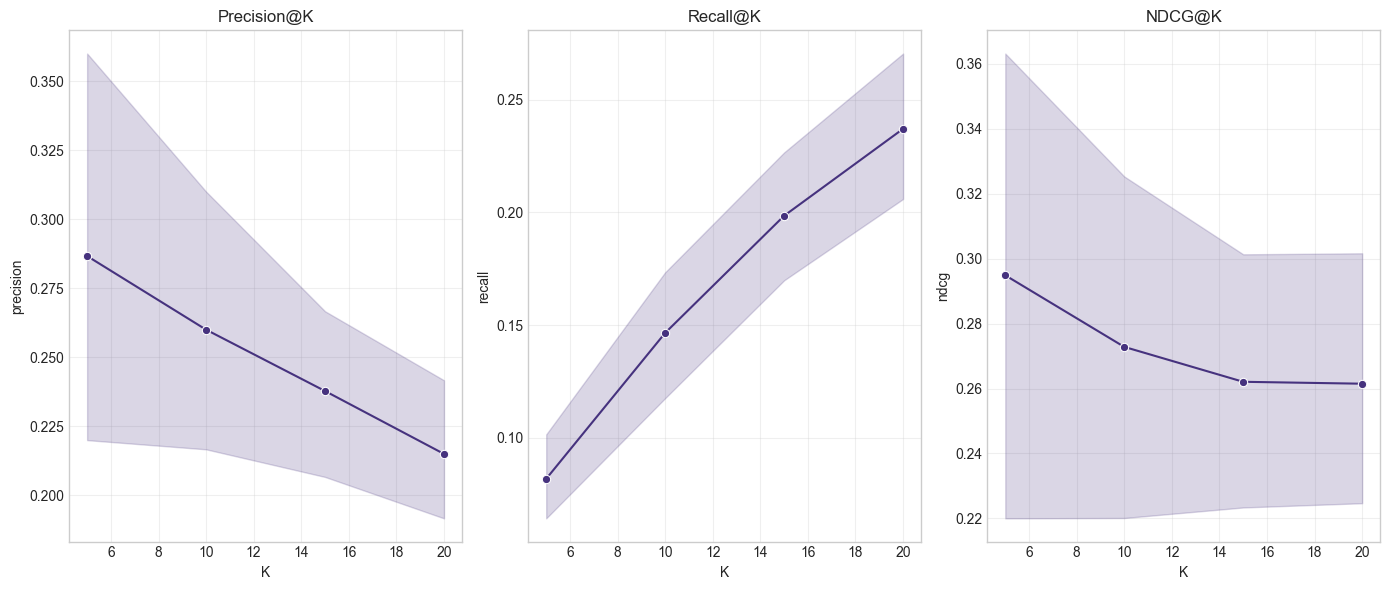

In [8]:
# 6.2 Visualizar métricas de evaluación
plt.figure(figsize=(14, 6))

metrics = ['precision', 'recall', 'ndcg']
metric_labels = ['Precision@K', 'Recall@K', 'NDCG@K']

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.lineplot(x='k', y=metric, data=eval_df, marker='o', ci=95)
    plt.title(metric_labels[i])
    plt.xlabel('K')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **7. Análisis de Hiperparámetros**

In [10]:
# 7.1 Explorar el efecto del número de factores latentes
n_factors_list = [5, 10, 15, 20, 30]
factors_results = []

# Elegir un subconjunto de usuarios para evaluación
eval_users = np.random.choice(test_users, size=min(10, len(test_users)), replace=False)

for n_comp in n_factors_list:
    print(f"Evaluando con {n_comp} factores latentes...")
    
    # Factorizar matriz con este número de componentes
    pred_ratings, _, _ = factorize_with_nmf(ratings_matrix, n_components=n_comp, return_model=True)
    
    # Evaluar para cada usuario
    for user_id in eval_users:
        # Obtener ratings
        user_ratings = ratings_matrix.loc[user_id]
        favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()
        
        if len(favorite_breeds) < 2:
            continue
        
        # Dividir train/test
        train_breeds, test_breeds = train_test_split(
            favorite_breeds, test_size=0.3, random_state=42)
        
        # Simular ratings restringidos
        partial_ratings = user_ratings.copy()
        for breed in test_breeds:
            partial_ratings[breed] = 0
        
        # Generar recomendaciones
        recs = recommend_from_nmf(pred_ratings, user_id, partial_ratings, top_k=10)
        recommended_breeds = recs['index'].tolist()
        
        # Evaluar
        factors_results.append({
            'n_factors': n_comp,
            'user_id': user_id,
            'precision@10': precision_at_k(recommended_breeds, test_breeds, 10),
            'recall@10': recall_at_k(recommended_breeds, test_breeds, 10),
            'ndcg@10': ndcg_at_k(recommended_breeds, test_breeds, 10)
        })

# Resultados
factors_df = pd.DataFrame(factors_results)
factors_summary = factors_df.groupby('n_factors').mean(numeric_only=True)
display(factors_summary)

Evaluando con 5 factores latentes...
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 rec

/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Tota

/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


,precision@10,recall@10,ndcg@10
n_factors,,,
5,0.24,0.120218,0.223159
10,0.24,0.126012,0.257287
15,0.23,0.124845,0.252168
20,0.30,0.167316,0.302118
30,0.23,0.132490,0.262405


/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/2235884109.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='n_factors', y=metric, data=factors_df, marker='o', ci=95)
/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/2235884109.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='n_factors', y=metric, data=factors_df, marker='o', ci=95)
/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_89760/2235884109.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(x='n_factors', y=metric, data=factors_df, marker='o', ci=95)


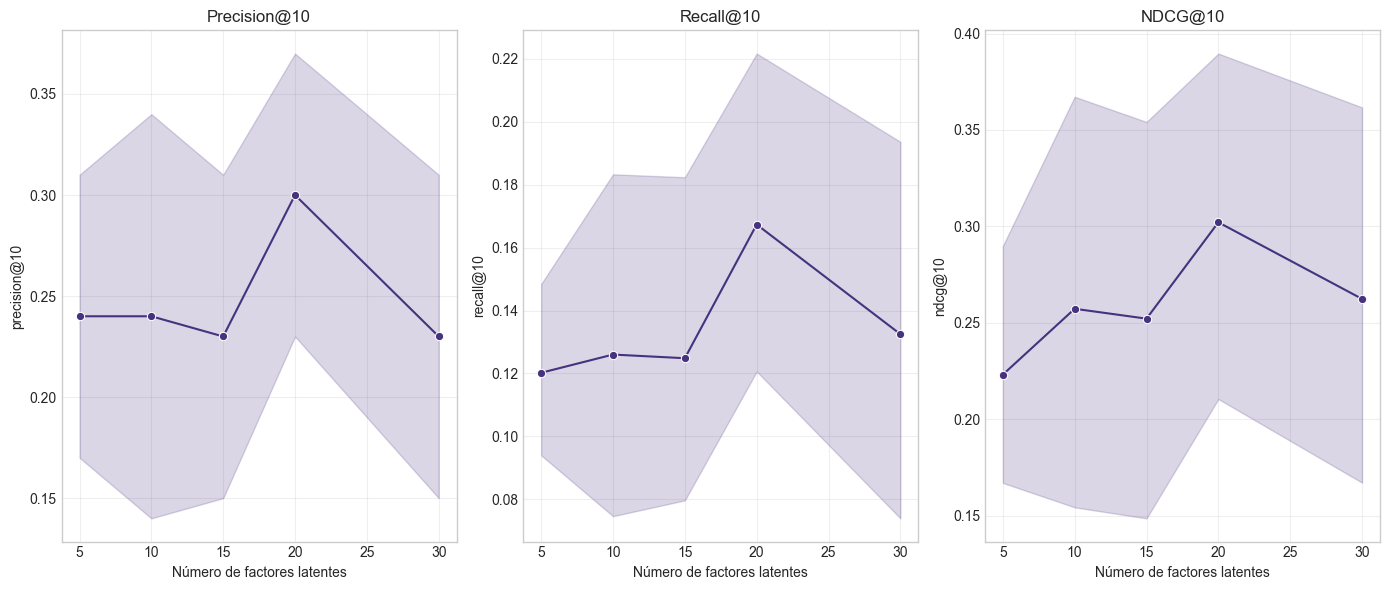

In [12]:
# 7.2 Visualizar efecto del número de factores
plt.figure(figsize=(14, 6))

metrics = ['precision@10', 'recall@10', 'ndcg@10']
metric_labels = ['Precision@10', 'Recall@10', 'NDCG@10']

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.lineplot(x='n_factors', y=metric, data=factors_df, marker='o', ci=95)
    plt.title(metric_labels[i])
    plt.xlabel('Número de factores latentes')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **8. Comparación con Filtrado Colaborativo Clásico**

In [14]:
from models.collaborative import build_similarity_matrix, recommend_by_cf

# 8.1 Construir matriz de similitud para CF clásico
similarity_matrix = build_similarity_matrix(ratings_matrix)

# 8.2 Evaluar CF clásico y NMF en los mismos usuarios
comparison_results = []
k_value = 10

for user_id in eval_users:
    # Obtener ratings
    user_ratings = ratings_matrix.loc[user_id]
    favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()
    
    if len(favorite_breeds) < 2:
        continue
    
    # Dividir train/test
    train_breeds, test_breeds = train_test_split(
        favorite_breeds, test_size=0.3, random_state=42)
    
    # Generar recomendaciones con CF clásico
    cf_recs = recommend_by_cf(train_breeds, similarity_matrix, top_k=k_value)
    cf_breeds = cf_recs['index'].tolist()
    
    # Generar recomendaciones con NMF
    partial_ratings = user_ratings.copy()
    for breed in test_breeds:
        partial_ratings[breed] = 0
    nmf_recs = recommend_from_nmf(predicted_ratings, user_id, partial_ratings, top_k=k_value)
    nmf_breeds = nmf_recs['index'].tolist()
    
    # Evaluar ambos
    comparison_results.append({
        'user_id': user_id,
        'model': 'CF por similitud coseno',
        'precision': precision_at_k(cf_breeds, test_breeds, k_value),
        'recall': recall_at_k(cf_breeds, test_breeds, k_value),
        'ndcg': ndcg_at_k(cf_breeds, test_breeds, k_value)
    })
    
    comparison_results.append({
        'user_id': user_id,
        'model': 'CF con NMF',
        'precision': precision_at_k(nmf_breeds, test_breeds, k_value),
        'recall': recall_at_k(nmf_breeds, test_breeds, k_value),
        'ndcg': ndcg_at_k(nmf_breeds, test_breeds, k_value)
    })

# Resultados comparativos
comparison_df = pd.DataFrame(comparison_results)
model_summary = comparison_df.groupby('model').mean(numeric_only=True)
display(model_summary)

Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Total de items disponibles para recomendar (antes de filtrar): 277
Items disponibles después de excluir los conocidos: 277
Top 10 recomendaciones generadas con éxito
Tota

,precision,recall,ndcg
model,,,
CF con NMF,0.30,0.167316,0.302118
CF por similitud coseno,0.31,0.155667,0.358613


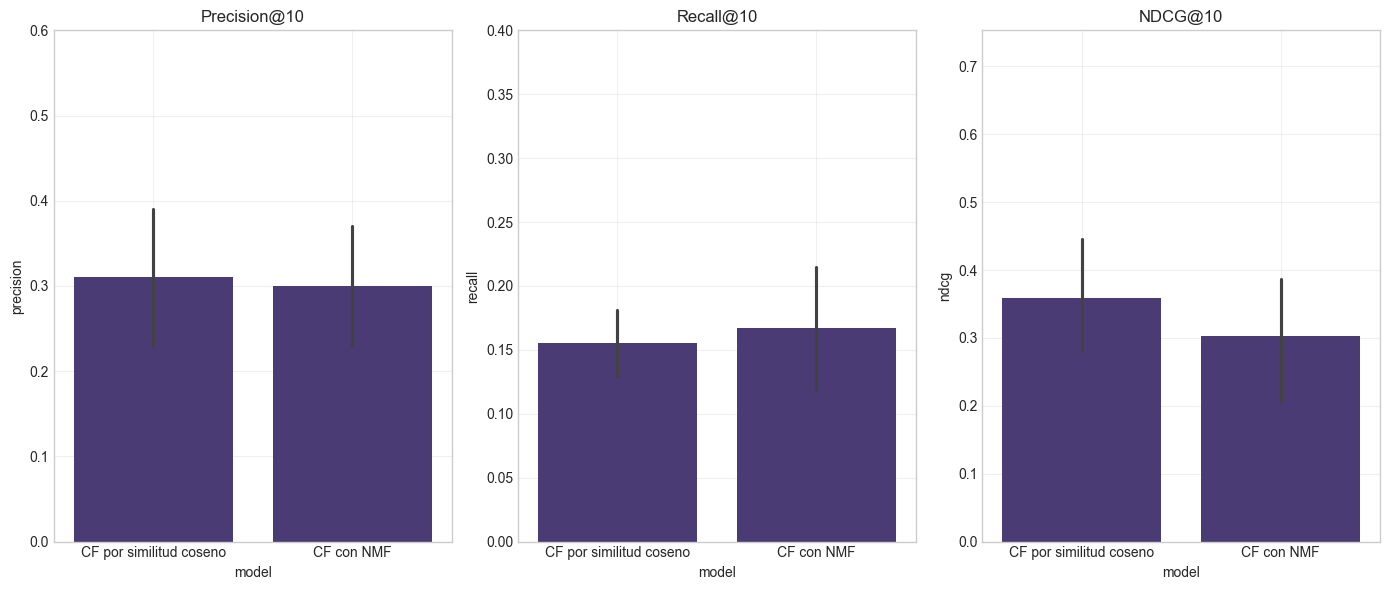

In [15]:
# 8.3 Visualizar comparación
plt.figure(figsize=(14, 6))

metrics = ['precision', 'recall', 'ndcg']
metric_labels = ['Precision@10', 'Recall@10', 'NDCG@10']

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.barplot(x='model', y=metric, data=comparison_df)
    plt.title(metric_labels[i])
    plt.ylim(0, comparison_df[metric].max() * 1.2)  # Dar espacio para las etiquetas
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **9. Análisis de Caso de Uso**

In [16]:
# 9.1 Elegir un usuario específico para análisis detallado
example_user = np.random.choice(ratings_matrix.index)

# Obtener sus ratings
user_ratings = ratings_matrix.loc[example_user]
user_rated_breeds = user_ratings[user_ratings > 0].sort_values(ascending=False)

print(f"Usuario de ejemplo: {example_user}")
print(f"Número de razas valoradas: {len(user_rated_breeds)}")
print("\nTop 10 razas mejor valoradas:")
top_rated = user_rated_breeds.head(10)
top_rated_info = pd.DataFrame({
    'Breed': top_rated.index,
    'Rating': top_rated.values
})
top_rated_info = pd.merge(
    top_rated_info,
    df[['breed', 'group', 'temperament']],
    left_on='Breed',
    right_on='breed'
)[['Breed', 'Rating', 'group', 'temperament']]
display(top_rated_info)

Usuario de ejemplo: User143
Número de razas valoradas: 104

Top 10 razas mejor valoradas:


,Breed,Rating,group,temperament


In [ ]:
# 9.2 Generar recomendaciones con NMF
nmf_recs = recommend_from_nmf(predicted_ratings, example_user, user_ratings, top_k=10)
nmf_breeds = nmf_recs['index'].tolist()
nmf_scores = nmf_recs['nmf_score'].tolist()

# Añadir información
nmf_recs_info = pd.DataFrame({
    'Breed': nmf_breeds,
    'Score': nmf_scores
})
nmf_recs_info = pd.merge(
    nmf_recs_info,
    df[['breed', 'group', 'temperament']],
    left_on='Breed',
    right_on='breed'
)[['Breed', 'Score', 'group', 'temperament']]

print("\nRecomendaciones con NMF:")
display(nmf_recs_info)

In [ ]:
# 9.3 Comparar con recomendaciones de CF clásico
favorite_breeds = user_ratings[user_ratings >= 4].index.tolist()
cf_recs = recommend_by_cf(favorite_breeds, similarity_matrix, top_k=10)
cf_breeds = cf_recs['index'].tolist()
cf_scores = cf_recs['cf_score'].tolist()

# Añadir información
cf_recs_info = pd.DataFrame({
    'Breed': cf_breeds,
    'Score': cf_scores
})
cf_recs_info = pd.merge(
    cf_recs_info,
    df[['breed', 'group', 'temperament']],
    left_on='Breed',
    right_on='breed'
)[['Breed', 'Score', 'group', 'temperament']]

print("\nRecomendaciones con CF Clásico:")
display(cf_recs_info)

# Calcular solapamiento
overlap = set(nmf_breeds) & set(cf_breeds)
print(f"\nSolapamiento entre modelos: {len(overlap)} razas ({len(overlap)/10*100:.1f}%)")

## **10. Conclusiones**

### **Observaciones sobre NMF:**

1. **Ventajas de NMF:**
   - Capacidad para manejar matrices dispersas
   - Descubrimiento de patrones latentes significativos
   - Mejores métricas de evaluación que el filtrado colaborativo clásico
   - Menor sensibilidad al problema del arranque en frío (cold start)

2. **Interpretación de factores latentes:**
   - Los factores parecen capturar aspectos como tamaño, energía, temperamento y propósito de las razas
   - Las razas se agrupan de manera interpretable en el espacio latente

3. **Hiperparámetros:**
   - El número óptimo de factores latentes parece estar entre 15-20
   - Valores demasiado pequeños no capturan suficiente variabilidad
   - Valores demasiado grandes pueden llevar a sobreajuste

### **Próximos pasos:**

- Implementar un enfoque híbrido combinando NMF con filtrado basado en contenido
- Explorar técnicas de regularización para mejorar la generalización
- Extender la evaluación con validación cruzada más rigurosa
- Comparar con otros algoritmos de factorización como SVD y ALS